# Deep Learning Basics in PyTorch

Portfolio version by `@pkim02`.

This notebook is a cleaned project version derived from coursework. The implementation code and executed results are preserved, while submission instructions, personal identifiers, assignment boilerplate, and course-provided image references were removed.

**Project focus:** A PyTorch implementation notebook for linear regression, logistic regression, and feedforward neural networks, including MNIST classification experiments.


## Implementation Notes

The code cells below contain the implemented model, training, evaluation, and visualization workflow. Most executed outputs are kept so the notebook can be reviewed without rerunning the full experiment.


In [1]:
import datetime
print("This code is written at " + str(datetime.datetime.now()))


This code is written at 2026-03-10 05:38:34.149350


In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [3]:
# Creates 50 random x and y numbers
np.random.seed(1)
n = 50
x = np.random.randn(n)
y = x * np.random.randn(n)


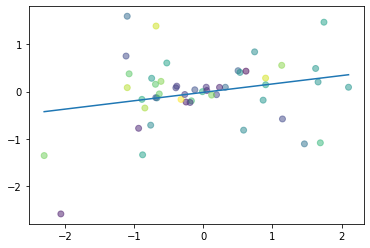

In [7]:
# Plots best-fit line via polyfit
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))

# Plots the random x and y data points we created
# Interestingly, alpha makes it more aesthetically pleasing
plt.scatter(x, y, c=np.random.rand(n), alpha=0.5)
plt.show()


In [8]:
x_values = [i for i in range(11)]


In [9]:
# Convert to numpy
x_train = np.array(x_values, dtype=np.float32)
print(x_train.shape)


(11,)


In [10]:
# IMPORTANT: 2D required
x_train = x_train.reshape(-1, 1)
print(x_train.shape)


(11, 1)


In [11]:
y_values = [2*i + 1 for i in x_values]


In [12]:
print(y_values)


[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]


In [30]:
# In case you're weak in list iterators...
y_values = []
for i in x_values:
    result = 2*i + 1
    y_values.append(result)


In [33]:
print(y_values)


[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]


In [13]:
y_train = np.array(y_values, dtype=np.float32)
print(y_train.shape)


(11,)


In [14]:
# IMPORTANT: 2D required
y_train = y_train.reshape(-1, 1)
print(y_train.shape)


(11, 1)


In [15]:
import torch
import torch.nn as nn


In [16]:
# Create class
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  

    def forward(self, x):
        out = self.linear(x)
        return out


In [17]:
model = LinearRegressionModel(input_dim=1, output_dim=1)


In [18]:
criterion = nn.MSELoss()


In [19]:
learning_rate = 0.01

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [20]:
epochs = 100


In [21]:
for epoch in range(epochs):
    epoch += 1
    # Convert numpy array to torch Variable
    inputs = torch.from_numpy(x_train)
    labels = torch.from_numpy(y_train)

    # Clear gradients w.r.t. parameters
    optimizer.zero_grad() 

    # Forward to get output
    outputs = model(inputs)

    # Calculate Loss
    loss = criterion(outputs, labels)

    # Getting gradients w.r.t. parameters
    loss.backward()

    # Updating parameters
    optimizer.step()
    if epoch % 10 == 0:
        print('epoch {}, loss {}'.format(epoch, loss.item()))


epoch 10, loss 0.0008409358561038971
epoch 20, loss 0.0007516065961681306
epoch 30, loss 0.0006717756041325629
epoch 40, loss 0.00060042436234653
epoch 50, loss 0.0005366411642171443
epoch 60, loss 0.00047962667304091156
epoch 70, loss 0.0004286882176529616
epoch 80, loss 0.0003831526555586606
epoch 90, loss 0.00034245222923345864
epoch 100, loss 0.0003060736635234207


In [22]:
# Purely inference
predicted = model(torch.from_numpy(x_train)).data.numpy()


In [23]:
predicted


array([[ 1.0325444],
       [ 3.0278578],
       [ 5.023171 ],
       [ 7.018484 ],
       [ 9.013798 ],
       [11.00911  ],
       [13.004424 ],
       [14.999737 ],
       [16.99505  ],
       [18.990364 ],
       [20.985678 ]], dtype=float32)

In [24]:
# y = 2x + 1 
y_train


array([[ 1.],
       [ 3.],
       [ 5.],
       [ 7.],
       [ 9.],
       [11.],
       [13.],
       [15.],
       [17.],
       [19.],
       [21.]], dtype=float32)

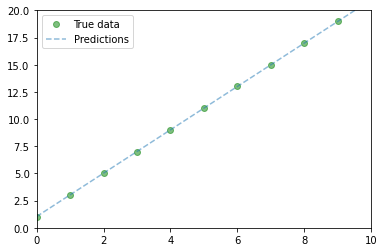

In [25]:
# Clear figure
plt.clf()

# Get predictions
predicted = model(torch.from_numpy(x_train)).data.numpy()

# Plot true data
plt.plot(x_train, y_train, 'go', label='True data', alpha=0.5)

# Plot predictions
plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)

# Legend and plot
plt.legend(loc='best')
plt.xlim(0, 10)
plt.ylim(0, 20)
plt.show()


In [26]:
save_model = False
if save_model is True:
    # Saves only parameters
    # alpha & beta
    torch.save(model.state_dict(), 'awesome_model.pkl')


In [27]:
load_model = False
if load_model is True:
    model.load_state_dict(torch.load('awesome_model.pkl'))


In [28]:
import torch
import torch.nn as nn

'''
STEP 1: CREATE MODEL CLASS
'''
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  

    def forward(self, x):
        out = self.linear(x)
        return out

'''
STEP 2: INSTANTIATE MODEL CLASS
'''
model = LinearRegressionModel(input_dim=1, output_dim=1)

'''
STEP 3: INSTANTIATE LOSS CLASS
'''

criterion = nn.MSELoss()

'''
STEP 4: INSTANTIATE OPTIMIZER CLASS
'''

learning_rate = 0.01

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

'''
STEP 5: TRAIN THE MODEL
'''
epochs = 100
for epoch in range(epochs):
    epoch += 1
    # Convert numpy array to torch Variable
    inputs = torch.from_numpy(x_train)
    labels = torch.from_numpy(y_train)

    # Clear gradients w.r.t. parameters
    optimizer.zero_grad() 

    # Forward to get output
    outputs = model(inputs)

    # Calculate Loss
    loss = criterion(outputs, labels)

    # Getting gradients w.r.t. parameters
    loss.backward()

    # Updating parameters
    optimizer.step()
    
    if epoch % 10 == 0:
        print('epoch {}, loss {}'.format(epoch, loss.item()))


epoch 10, loss 0.27092283964157104
epoch 20, loss 0.24214543402194977
epoch 30, loss 0.21642421185970306
epoch 40, loss 0.19343547523021698
epoch 50, loss 0.17288874089717865
epoch 60, loss 0.15452423691749573
epoch 70, loss 0.13811057806015015
epoch 80, loss 0.12344028800725937
epoch 90, loss 0.11032842844724655
epoch 100, loss 0.09860933572053909


In [29]:
print(f"the number of available gpus: {torch.cuda.device_count()}")
print(f"Is available?: {torch.cuda.is_available()}")
print(f"Device name: {torch.cuda.get_device_name()}")


the number of available gpus: 1
Is available?: True
Device name: NVIDIA RTX 5000 Ada Generation


In [30]:
import torch
import torch.nn as nn
import numpy as np

'''
STEP 1: CREATE MODEL CLASS
'''
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)  

    def forward(self, x):
        out = self.linear(x)
        return out

'''
STEP 2: INSTANTIATE MODEL CLASS
'''
model = LinearRegressionModel(input_dim=1, output_dim=1)


#  USE GPU FOR MODEL  #

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

'''
STEP 3: INSTANTIATE LOSS CLASS
'''

criterion = nn.MSELoss()

'''
STEP 4: INSTANTIATE OPTIMIZER CLASS
'''

learning_rate = 0.01

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

'''
STEP 5: TRAIN THE MODEL
'''
epochs = 100
for epoch in range(epochs):
    epoch += 1
    # Convert numpy array to torch Variable

    #  USE GPU FOR MODEL  #
    inputs = torch.from_numpy(x_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    # Clear gradients w.r.t. parameters
    optimizer.zero_grad() 

    # Forward to get output
    outputs = model(inputs)

    # Calculate Loss
    loss = criterion(outputs, labels)

    # Getting gradients w.r.t. parameters
    loss.backward()

    # Updating parameters
    optimizer.step()

    # Logging
    if epoch % 10 == 0:
        print('epoch {}, loss {}'.format(epoch, loss.item()))


epoch 10, loss 0.010166783817112446
epoch 20, loss 0.009070995263755322
epoch 30, loss 0.008166803978383541
epoch 40, loss 0.007316341623663902
epoch 50, loss 0.0064785978756845
epoch 60, loss 0.0058326018042862415
epoch 70, loss 0.005183749366551638
epoch 80, loss 0.004684514366090298
epoch 90, loss 0.004140493925660849
epoch 100, loss 0.0037524369545280933


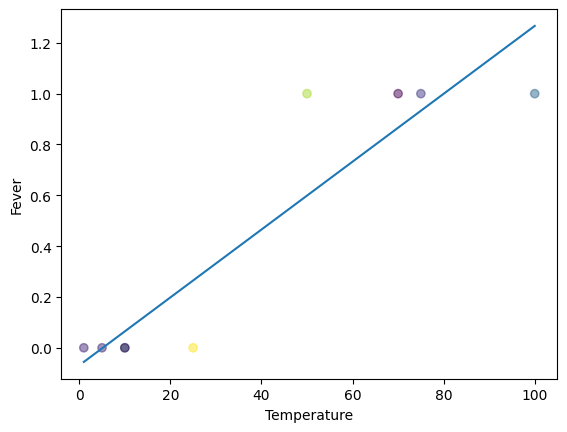

In [88]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x = [1, 5, 10, 10, 25, 50, 70, 75, 100,]
y = [0, 0, 0, 0, 0, 1, 1, 1, 1]

colors = np.random.rand(len(x))
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
plt.ylabel("Fever")
plt.xlabel("Temperature")

plt.scatter(x, y, c=colors, alpha=0.5)
plt.show()


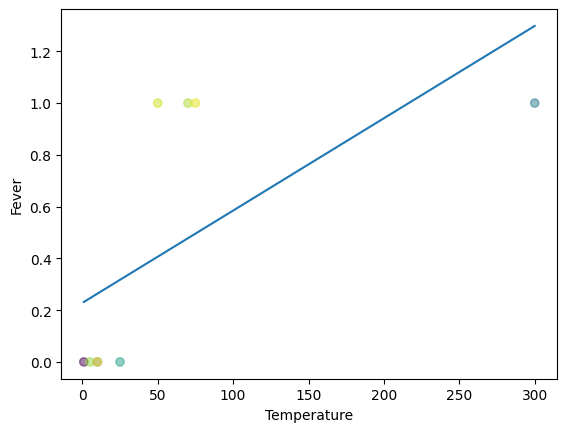

In [89]:
import numpy as np
import matplotlib.pyplot as plt

x = [1, 5, 10, 10, 25, 50, 70, 75, 300]
y = [0, 0, 0, 0, 0, 1, 1, 1, 1]

colors = np.random.rand(len(x))
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))(np.unique(x)))
plt.ylabel("Fever")
plt.xlabel("Temperature")

plt.scatter(x, y, c=colors, alpha=0.5)
plt.show()


In [90]:
import math
print(-math.log(1 - 0.00001))


1.0000050000287824e-05


In [91]:
print(-math.log(1 - 0.99999))


11.51292546497478


In [92]:
print(-math.log(0.99999))


1.0000050000287824e-05


In [93]:
print(-math.log(0.00001))


11.512925464970229


In [94]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets


In [95]:
train_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=True, 
    transform=transforms.ToTensor(),
    download=True
)

len(train_dataset)


60000

In [96]:
train_dataset[0]


(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [97]:
type(train_dataset[0])


tuple

In [100]:
# Input Matrix
print(train_dataset[0][0].shape)


torch.Size([1, 28, 28])


In [101]:
# Label
train_dataset[0][1]


5

In [102]:
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np


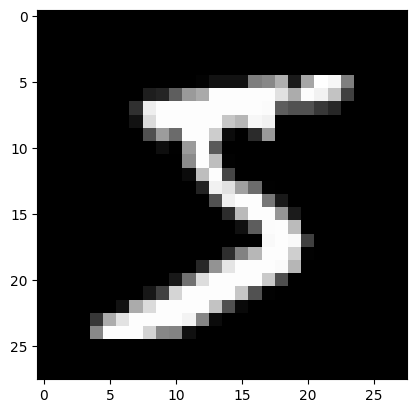

In [105]:
plt.imshow(train_dataset[0][0].numpy().reshape(28, 28), cmap='gray')


In [110]:
# Label
print(train_dataset[0][1])


5


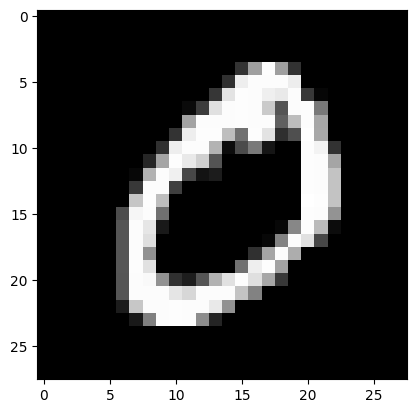

In [111]:
plt.imshow(train_dataset[1][0].numpy().reshape(28, 28), cmap='gray')


In [112]:
# Label
print(train_dataset[1][1])


0


In [113]:
test_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=False, 
    transform=transforms.ToTensor()
)


In [114]:
len(test_dataset)


10000

In [115]:
type(test_dataset[0])


tuple

In [117]:
# Image matrix
print(test_dataset[0][0].shape)


torch.Size([1, 28, 28])


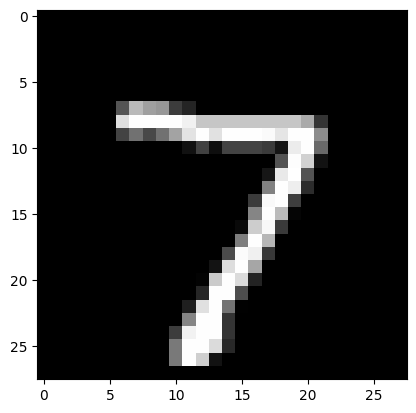

In [118]:
plt.imshow(test_dataset[0][0].numpy().reshape(28, 28), cmap='gray')


In [119]:
# Label
print(test_dataset[0][1])


7


In [120]:
len(train_dataset)


60000

In [121]:
batch_size = 100


In [122]:
n_iters = 3000


In [124]:
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)
print(num_epochs)


5


In [125]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)


In [127]:
# Iterable object
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)


In [129]:
img_1 = np.ones((28, 28))
img_2 = np.ones((28, 28))
lst = [img_1, img_2]


In [130]:
# Need to iterate
# Think of numbers as the images
for i in lst:
    print(i.shape)


(28, 28)
(28, 28)


In [131]:
# Same as linear regression! 
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.linear(x)
        return out


In [132]:
# Size of images
print(train_dataset[0][0].shape)


torch.Size([1, 28, 28])


In [133]:
model = LogisticRegressionModel(input_dim=28 * 28, output_dim=10)


In [134]:
criterion = nn.CrossEntropyLoss()


In [135]:
learning_rate = 0.001

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [136]:
# Type of parameter object
print(model.parameters())


<generator object Module.parameters at 0x7f9e6e965580>


In [137]:
# Length of parameters
print(len(list(model.parameters())))


2


In [138]:
list(model.parameters())


[Parameter containing:
 tensor([[-0.0027,  0.0171, -0.0341,  ..., -0.0226,  0.0035,  0.0307],
         [-0.0265, -0.0074,  0.0136,  ...,  0.0156,  0.0255,  0.0334],
         [ 0.0346, -0.0018, -0.0155,  ..., -0.0206, -0.0233,  0.0020],
         ...,
         [ 0.0088,  0.0085,  0.0044,  ..., -0.0234, -0.0198,  0.0212],
         [-0.0034,  0.0233,  0.0298,  ..., -0.0303, -0.0347, -0.0042],
         [-0.0007, -0.0236,  0.0068,  ..., -0.0333, -0.0180,  0.0297]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0201,  0.0320, -0.0066, -0.0339,  0.0322, -0.0142,  0.0246, -0.0300,
         -0.0029, -0.0352], requires_grad=True)]

In [139]:
# FC 1 Parameters 
print(list(model.parameters())[0].size())


torch.Size([10, 784])


In [140]:
# FC 1 Bias Parameters
print(list(model.parameters())[1].size())


torch.Size([10])


In [141]:
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Load images as Variable
        images = images.view(-1, 28*28)
        labels = labels

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images)

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                # Load images to a Torch Variable
                images = images.view(-1, 28*28)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs.data, 1)

                # Total number of labels
                total += labels.size(0)

                # Total correct predictions
                correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total

            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))


Iteration: 500. Loss: 1.9004325866699219. Accuracy: 65.09
Iteration: 1000. Loss: 1.6131913661956787. Accuracy: 74.32
Iteration: 1500. Loss: 1.2722251415252686. Accuracy: 77.81
Iteration: 2000. Loss: 1.224632978439331. Accuracy: 79.83
Iteration: 2500. Loss: 1.079829454421997. Accuracy: 81.49
Iteration: 3000. Loss: 1.0169812440872192. Accuracy: 82.29


In [147]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28)
    outputs = model(images)
    if iter_test == 1:
        print(f'OUTPUTS SHAPE: {outputs.shape}')
        _, predicted = torch.max(outputs.data, 1)
        print(f'PREDICTION SHAPE: {predicted.shape}')
        print(predicted)
        break


OUTPUTS SHAPE: torch.Size([100, 10])
PREDICTION SHAPE: torch.Size([100])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 2, 9, 0, 0, 9, 0, 1, 3, 9, 7, 3, 4, 7, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 0, 7, 2, 7, 1, 3, 1, 1, 7, 4, 2, 3, 3, 3, 2,
        4, 4, 6, 3, 5, 3, 2, 8, 4, 1, 9, 5, 7, 2, 9, 2, 7, 9, 2, 4, 3, 0, 7, 0,
        2, 8, 1, 7, 3, 7, 1, 7, 9, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 8, 3, 1, 4,
        1, 1, 6, 9])


In [152]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28)
    outputs = model(images)
    if iter_test == 1:
        print(f'OUTPUT of 1st sample: \n{outputs[0, :]}\n')
        print(f'OUTPUT of 2nd sample: \n{outputs[1, :]}')
        break


OUTPUT of 1st sample: 
tensor([-0.4926, -1.1943, -0.2733, -0.2753, -0.0519, -0.5080, -0.9716,  2.7432,
        -0.4171,  0.7136], grad_fn=<SliceBackward0>)

OUTPUT of 2nd sample: 
tensor([ 0.3960,  0.3382,  1.3953,  1.1716, -1.7173,  0.5447,  1.0745, -2.0084,
         0.2351, -1.6468], grad_fn=<SliceBackward0>)


In [160]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28)
    outputs = model(images)
    values, predicted = outputs.max(dim=1)
    if iter_test == 1:
        print(f'PREDICTION SHAPE: {predicted.shape}')
        print(predicted)
        break


PREDICTION SHAPE: torch.Size([100])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 2, 9, 0, 0, 9, 0, 1, 3, 9, 7, 3, 4, 7, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 0, 7, 2, 7, 1, 3, 1, 1, 7, 4, 2, 3, 3, 3, 2,
        4, 4, 6, 3, 5, 3, 2, 8, 4, 1, 9, 5, 7, 2, 9, 2, 7, 9, 2, 4, 3, 0, 7, 0,
        2, 8, 1, 7, 3, 7, 1, 7, 9, 6, 2, 7, 8, 4, 7, 3, 6, 1, 3, 6, 8, 3, 1, 4,
        1, 1, 6, 9])


In [164]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28)
    outputs = model(images)
    values, predicted = outputs.max(dim=1)
    if iter_test == 1:
        print(f'PREDICTION of 1st sample: {predicted[0]}')
        break


PREDICTION of 1st sample: 7


In [167]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28)
    outputs = model(images)
    values, predicted = outputs.max(dim=1)
    if iter_test == 1:
        print(f'PREDICTION of 1st sample: {predicted[0]}')
        print(f'Groundtruth of 1st sample: {labels[0]}')
        break


PREDICTION of 1st sample: 7
Groundtruth of 1st sample: 7


In [169]:
iter_test = 0
for images, labels in test_loader:
    iter_test += 1
    images = images.view(-1, 28*28)
    outputs = model(images)
    values, predicted = outputs.max(dim=1)

    if iter_test == 1:
        print(f'PREDICTION of 2nd sample: {predicted[1]}')
        print(f'Groundtruth of 2nd sample: {labels[1]}')
        break


PREDICTION of 2nd sample: 2
Groundtruth of 2nd sample: 2


In [174]:
correct = 0
total = 0
for images, labels in test_loader:
    images = images.view(-1, 28*28)
    outputs = model(images)
    values, predicted = outputs.max(dim=1)

    # Total number of labels
    total += labels.shape[0]

    # Total correct predictions
    correct += (predicted == labels).sum()

accuracy = 100 * (correct.item() / total)
print(f"accuracy: {accuracy:.2f}")


accuracy: 82.29


In [175]:
# Explaining .sum() python built-in function
# correct += (predicted == labels).sum()
import numpy as np

a = np.ones((10))
print(f"a: {a}")

b = np.array([0. for i in range(5)]+[1. for i in range(5)])
print(f"b: {b}")

print(f"{a == b}")

print(f"{(a == b).sum()}")


a: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
b: [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
[False False False False False  True  True  True  True  True]
5


In [176]:
save_model = False
if save_model is True:
    # Saves only parameters
    torch.save(model.state_dict(), 'awesome_model.pkl')


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

'''
STEP 1: LOADING DATASET
'''

train_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
test_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=False,
    transform=transforms.ToTensor()
)

'''
STEP 2: MAKING DATASET ITERABLE
'''

batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

'''
STEP 3: CREATE MODEL CLASS
'''
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        out = self.linear(x)
        return out

'''
STEP 4: INSTANTIATE MODEL CLASS
'''
model = LogisticRegressionModel(input_size=28*28, num_classes=10)

'''
STEP 5: INSTANTIATE LOSS CLASS
'''
criterion = nn.CrossEntropyLoss()

'''
STEP 6: INSTANTIATE OPTIMIZER CLASS
'''
learning_rate = 0.001
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

'''
STEP 7: TRAIN THE MODEL
'''
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Load images as Variable
        images = images.view(-1, 28*28)
        labels = labels

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        # 100 x 10
        outputs = model(images)

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                # Load images to a Torch Variable
                images = images.view(-1, 28*28)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                # 100 x 1
                _, predicted = torch.max(outputs.data, 1)

                # Total number of labels
                total += labels.size(0)

                # Total correct predictions
                correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total

            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))


In [179]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

'''
STEP 1: LOADING DATASET
'''

train_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
test_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=False,
    transform=transforms.ToTensor()
)

'''
STEP 2: MAKING DATASET ITERABLE
'''

batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)
'''
STEP 3: CREATE MODEL CLASS
'''
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        out = self.linear(x)
        return out

'''
STEP 4: INSTANTIATE MODEL CLASS
'''
model = LogisticRegressionModel(input_size=28*28, num_classes=10)

#  USE GPU FOR MODEL  #

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

'''
STEP 5: INSTANTIATE LOSS CLASS
'''
criterion = nn.CrossEntropyLoss()

'''
STEP 6: INSTANTIATE OPTIMIZER CLASS
'''
learning_rate = 0.001

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

'''
STEP 7: TRAIN THE MODEL
'''
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        #  USE GPU FOR MODEL  #
        images = images.view(-1, 28*28).to(device)  # [1, 784]
        labels = labels.to(device)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images)

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                #  USE GPU FOR MODEL  #
                images = images.view(-1, 28*28).to(device)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs.data, 1)

                # Total number of labels
                total += labels.size(0)

                #  USE GPU FOR MODEL  #
                # Total correct predictions
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total

            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))


Iteration: 500. Loss: 1.8348655700683594. Accuracy: 71.72
Iteration: 1000. Loss: 1.5112717151641846. Accuracy: 77.18
Iteration: 1500. Loss: 1.1990660429000854. Accuracy: 79.49
Iteration: 2000. Loss: 1.2101340293884277. Accuracy: 81.27
Iteration: 2500. Loss: 1.1190288066864014. Accuracy: 82.04
Iteration: 3000. Loss: 1.0212806463241577. Accuracy: 82.81


In [181]:
import torch
import torch.nn as nn


In [182]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.linear(x)
        return out


In [183]:
model = LogisticRegressionModel(input_dim=28*28, output_dim=10)


In [184]:
print(model)


LogisticRegressionModel(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


In [185]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets


In [186]:
'''
STEP 1: LOADING DATASET
'''
train_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
test_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=False,
    transform=transforms.ToTensor()
)


In [187]:
60000 / 100


600.0

In [188]:
600 * 5


3000

In [189]:
'''
STEP 2: MAKING DATASET ITERABLE
'''
batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [190]:
'''
STEP 3: CREATE MODEL CLASS
'''
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Linear function
        self.fc1 = nn.Linear(input_dim, hidden_dim) 

        # Non-linearity
        self.sigmoid = nn.Sigmoid()

        # Linear function (readout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)  

    def forward(self, x):
        # Linear function  # LINEAR
        out = self.fc1(x)

        # Non-linearity  # NON-LINEAR
        out = self.sigmoid(out)

        # Linear function (readout)  # LINEAR
        out = self.fc2(out)
        return out


In [191]:
'''
STEP 4: INSTANTIATE MODEL CLASS
'''
model = FeedforwardNeuralNetModel(input_dim=28*28, hidden_dim=100, output_dim=10)


In [192]:
'''
STEP 5: INSTANTIATE LOSS CLASS
'''
criterion = nn.CrossEntropyLoss()


In [193]:
'''
STEP 6: INSTANTIATE OPTIMIZER CLASS
'''
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


In [194]:
print(model.parameters())


<generator object Module.parameters at 0x7f9e565d9dd0>


In [195]:
print(len(list(model.parameters())))


4


In [196]:
# FC 1 Parameters 
print(list(model.parameters())[0].size())


torch.Size([100, 784])


In [197]:
# FC 1 Bias Parameters
print(list(model.parameters())[1].size())


torch.Size([100])


In [198]:
# FC 2 Parameters
print(list(model.parameters())[2].size())


torch.Size([10, 100])


In [199]:
# FC 2 Bias Parameters
print(list(model.parameters())[3].size())


torch.Size([10])


In [ ]:
'''
STEP 7: TRAIN THE MODEL
'''
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Load images with gradient accumulation capabilities
        images = images.view(-1, 28*28)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images)

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                # Load images with gradient accumulation capabilities
                images = images.view(-1, 28*28)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs.data, 1)

                # Total number of labels
                total += labels.size(0)

                # Total correct predictions
                correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total

            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))


In [ ]:
'''
STEP 3: CREATE MODEL CLASS
'''
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Linear function
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        # Non-linearity
        self.tanh = nn.Tanh()
        # Linear function (readout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)  

    def forward(self, x):
        # Linear function
        out = self.fc1(x)
        # Non-linearity
        out = self.tanh(out)
        # Linear function (readout)
        out = self.fc2(out)
        return out


In [ ]:
'''
STEP 3: CREATE MODEL CLASS
'''
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Linear function
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        # Non-linearity
        self.relu = nn.ReLU()
        # Linear function (readout)
        self.fc2 = nn.Linear(hidden_dim, output_dim)  

    def forward(self, x):
        # Linear function
        out = self.fc1(x)
        # Non-linearity
        out = self.relu(out)
        # Linear function (readout)
        out = self.fc2(out)
        return out


In [ ]:
'''
STEP 3: CREATE MODEL CLASS
'''
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Linear function 1: 784 --> 100
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        # Non-linearity 1
        self.relu1 = nn.ReLU()

        # Linear function 2: 100 --> 100
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2
        self.relu2 = nn.ReLU()

        # Linear function 3 (readout): 100 --> 10
        self.fc3 = nn.Linear(hidden_dim, output_dim)  

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.relu2(out)

        # Linear function 3 (readout)
        out = self.fc3(out)
        return out


In [ ]:
'''
STEP 3: CREATE MODEL CLASS
'''
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Linear function 1: 784 --> 100
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        # Non-linearity 1
        self.relu1 = nn.ReLU()

        # Linear function 2: 100 --> 100
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2
        self.relu2 = nn.ReLU()

        # Linear function 3: 100 --> 100
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3
        self.relu3 = nn.ReLU()

        # Linear function 4 (readout): 100 --> 10
        self.fc4 = nn.Linear(hidden_dim, output_dim)  

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.relu2(out)

        # Linear function 2
        out = self.fc3(out)
        # Non-linearity 2
        out = self.relu3(out)

        # Linear function 4 (readout)
        out = self.fc4(out)
        return out


In [200]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets

'''
STEP 1: LOADING DATASET
'''

train_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
test_dataset = dsets.MNIST(
    root='./dataset/MNIST/', 
    train=False,
    transform=transforms.ToTensor()
)


'''
STEP 2: MAKING DATASET ITERABLE
'''

batch_size = 100
n_iters = 3000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

'''
STEP 3: CREATE MODEL CLASS
'''
class FeedforwardNeuralNetModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # Linear function 1: 784 --> 100
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        # Non-linearity 1
        self.relu1 = nn.ReLU()

        # Linear function 2: 100 --> 100
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2
        self.relu2 = nn.ReLU()

        # Linear function 3: 100 --> 100
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3
        self.relu3 = nn.ReLU()

        # Linear function 4 (readout): 100 --> 10
        self.fc4 = nn.Linear(hidden_dim, output_dim)  

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.relu2(out)

        # Linear function 2
        out = self.fc3(out)
        # Non-linearity 2
        out = self.relu3(out)

        # Linear function 4 (readout)
        out = self.fc4(out)
        return out
'''
STEP 4: INSTANTIATE MODEL CLASS
'''
input_dim = 28*28
hidden_dim = 100
output_dim = 10

model = FeedforwardNeuralNetModel(input_dim, hidden_dim, output_dim)

#  USE GPU FOR MODEL  #

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

'''
STEP 5: INSTANTIATE LOSS CLASS
'''
criterion = nn.CrossEntropyLoss()

'''
STEP 6: INSTANTIATE OPTIMIZER CLASS
'''
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

'''
STEP 7: TRAIN THE MODEL
'''
iter = 0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):

        #  USE GPU FOR MODEL  #
        images = images.view(-1, 28*28).to(device)
        labels = labels.to(device)

        # Clear gradients w.r.t. parameters
        optimizer.zero_grad()

        # Forward pass to get output/logits
        outputs = model(images)

        # Calculate Loss: softmax --> cross entropy loss
        loss = criterion(outputs, labels)

        # Getting gradients w.r.t. parameters
        loss.backward()

        # Updating parameters
        optimizer.step()

        iter += 1

        if iter % 500 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images, labels in test_loader:
                #  USE GPU FOR MODEL  #
                images = images.view(-1, 28*28).to(device)

                # Forward pass only to get logits/output
                outputs = model(images)

                # Get predictions from the maximum value
                _, predicted = torch.max(outputs.data, 1)

                # Total number of labels
                total += labels.size(0)

                #  USE GPU FOR MODEL  #
                # Total correct predictions
                if torch.cuda.is_available():
                    correct += (predicted.cpu() == labels.cpu()).sum()
                else:
                    correct += (predicted == labels).sum()

            accuracy = 100 * correct.item() / total

            # Print Loss
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))


Iteration: 500. Loss: 0.3738187849521637. Accuracy: 90.75
Iteration: 1000. Loss: 0.23663002252578735. Accuracy: 93.05
Iteration: 1500. Loss: 0.0919632539153099. Accuracy: 95.01
Iteration: 2000. Loss: 0.1264691948890686. Accuracy: 95.98
Iteration: 2500. Loss: 0.09776218235492706. Accuracy: 96.22
Iteration: 3000. Loss: 0.033743999898433685. Accuracy: 97.09


## Results To Review

See the preserved output cells for training curves, metrics, predictions, visualizations, or heatmaps depending on the project. The repository README summarizes the main implementation choices and paper references.
